# Data Analytics with Python Internship Task 1 - Student Performance Dataset

## Step 1 - Importing the libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Importing the dataset

In [2]:
student_math_df = pd.read_csv("student/student-mat.csv", sep= ";")

In [3]:
student_math_df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [4]:
# Renaming the attributes
# Dictionary mapping original column names to improved, descriptive snake_case names
# This can be directly used in pandas: df.rename(columns=column_renames)

column_renames = {
    "school": "school_name",
    "sex": "student_sex",
    "age": "age",
    "address": "address_type",
    "famsize": "family_size",
    "Pstatus": "parents_cohabitation_status",
    "Medu": "mother_education_level",
    "Fedu": "father_education_level",
    "Mjob": "mother_job",
    "Fjob": "father_job",
    "reason": "school_choice_reason",
    "guardian": "guardian_type",
    "traveltime": "travel_time",
    "studytime": "weekly_study_time",
    "failures": "past_class_failures",
    "schoolsup": "extra_school_support",
    "famsup": "family_educational_support",
    "paid": "extra_paid_classes",
    "activities": "extracurricular_activities",
    "nursery": "attended_nursery",
    "higher": "wants_higher_education",
    "internet": "home_internet_access",
    "romantic": "in_romantic_relationship",
    "famrel": "family_relationship_quality",
    "freetime": "free_time_after_school",
    "goout": "going_out_with_friends",
    "Dalc": "workday_alcohol_consumption",
    "Walc": "weekend_alcohol_consumption",
    "health": "current_health_status",
    "absences": "number_of_absences",
    "G1": "first_period_grade",
    "G2": "second_period_grade",
    "G3": "final_grade"
}

In [5]:
student_math_df = student_math_df.rename(columns= column_renames)

## Basic information about the dataset

### Attributes for `student-math.csv` Dataset:

#### Demographic and Personal Attributes

| ID | Attribute | Description | Data Type & Range |
| :--- | :--- | :--- | :--- |
| **1** | **school_name** | Student's school | Binary (`GP`: Gabriel Pereira, `MS`: Mousinho da Silveira) |
| **2** | **student_sex** | Student's sex | Binary (`F`: Female, `M`: Male) |
| **3** | **age** | Student's age | Numeric (15 to 22) |
| **4** | **address_type** | Home address type | Binary (`U`: Urban, `R`: Rural) |
| **5** | **family_size** | Family size | Binary (`LE3`: ≤ 3, `GT3`: > 3) |
| **6** | **parents_cohabitation_status** | Parent's cohabitation status | Binary (`T`: Living together, `A`: Apart) |
| **7** | **mother_education_level** | Mother's education level | Numeric (`0`: None, `1`: 4th grade, `2`: 5th-9th grade, `3`: Secondary, `4`: Higher) |
| **8** | **father_education_level** | Father's education level | Numeric (`0`: None, `1`: 4th grade, `2`: 5th-9th grade, `3`: Secondary, `4`: Higher) |
| **9** | **mother_job** | Mother's occupation | Nominal (`teacher`, `health`, civil `services`, `at_home`, `other`) |
| **10** | **father_job** | Father's occupation | Nominal (`teacher`, `health`, civil `services`, `at_home`, `other`) |

---

#### Academic and Lifestyle Attributes

| ID | Attribute | Description | Data Type & Range |
| :--- | :--- | :--- | :--- |
| **11** | **school_choice_reason** | Reason for choosing school | Nominal (`home`, `reputation`, `course`, `other`) |
| **12** | **guardian_type** | Student's primary guardian | Nominal (`mother`, `father`, `other`) |
| **13** | **travel_time** | Home to school travel time | Numeric (`1`: <15 min, `2`: 15-30 min, `3`: 30-60 min, `4`: >1 hour) |
| **14** | **weekly_study_time** | Weekly study time | Numeric (`1`: <2 hours, `2`: 2-5 hours, `3`: 5-10 hours, `4`: >10 hours) |
| **15** | **past_class_failures** | Past class failures | Numeric (`n` if 1≤n<3, else `4`) |
| **16** | **extra_school_support** | Extra educational support | Binary (`yes`, `no`) |
| **17** | **family_educational_support** | Family educational support | Binary (`yes`, `no`) |
| **18** | **extra_paid_classes** | Extra paid subject classes | Binary (`yes`, `no`) |
| **19** | **extracurricular_activities** | Extra-curricular activities | Binary (`yes`, `no`) |
| **20** | **attended_nursery** | Attended nursery school | Binary (`yes`, `no`) |
| **21** | **wants_higher_education** | Wants to take higher education | Binary (`yes`, `no`) |
| **22** | **home_internet_access** | Internet access at home | Binary (`yes`, `no`) |
| **23** | **in_romantic_relationship** | In a romantic relationship | Binary (`yes`, `no`) |

---

#### Social and Health Attributes

| ID | Attribute | Description | Data Type & Range |
| :--- | :--- | :--- | :--- |
| **24** | **family_relationship_quality** | Quality of family relationships | Numeric (`1`: Very bad to `5`: Excellent) |
| **25** | **free_time_after_school** | Free time after school | Numeric (`1`: Very low to `5`: Very high) |
| **26** | **going_out_with_friends** | Going out with friends | Numeric (`1`: Very low to `5`: Very high) |
| **27** | **workday_alcohol_consumption** | Workday alcohol consumption | Numeric (`1`: Very low to `5`: Very high) |
| **28** | **weekend_alcohol_consumption** | Weekend alcohol consumption | Numeric (`1`: Very low to `5`: Very high) |
| **29** | **current_health_status** | Current health status | Numeric (`1`: Very bad to `5`: Very good) |
| **30** | **number_of_absences** | Number of school absences | Numeric (0 to 93) |

---

#### Course Subject Grades (Math)

| ID | Attribute | Description | Data Type & Range |
| :--- | :--- | :--- | :--- |
| **31** | **first_period_grade** | First period grade (originally G1) | Numeric (0 to 20) |
| **32** | **second_period_grade** | Second period grade (originally G2) | Numeric (0 to 20) |
| **33** | **final_grade** | Final grade (originally G3, Output Target) | Numeric (0 to 20) |

We have renamed the columns of the datasets with column names that are easier to understand.

Moving on to basic information about the math dataset:

## Dataset Exploration and cleaning

In [6]:
student_math_df.sample(4)

,school_name,student_sex,age,address_type,family_size,parents_cohabitation_status,mother_education_level,father_education_level,mother_job,father_job,...,family_relationship_quality,free_time_after_school,going_out_with_friends,workday_alcohol_consumption,weekend_alcohol_consumption,current_health_status,number_of_absences,first_period_grade,second_period_grade,final_grade
70,GP,M,16,U,GT3,T,3,1,other,other,...,4,3,2,1,1,5,0,13,15,15
321,GP,F,17,U,GT3,T,2,2,other,other,...,4,2,2,1,1,3,12,11,9,9
180,GP,M,16,U,GT3,T,4,3,teacher,other,...,3,4,3,2,3,3,10,9,8,8
352,MS,M,18,U,LE3,T,1,3,at_home,services,...,4,3,3,2,3,3,7,8,7,8


**Q1:  Check missing values (.isnull()).**

In [7]:
student_math_df.isnull().sum()

school_name                    0
student_sex                    0
age                            0
address_type                   0
family_size                    0
parents_cohabitation_status    0
mother_education_level         0
father_education_level         0
mother_job                     0
father_job                     0
school_choice_reason           0
guardian_type                  0
travel_time                    0
weekly_study_time              0
past_class_failures            0
extra_school_support           0
family_educational_support     0
extra_paid_classes             0
extracurricular_activities     0
attended_nursery               0
wants_higher_education         0
home_internet_access           0
in_romantic_relationship       0
family_relationship_quality    0
free_time_after_school         0
going_out_with_friends         0
workday_alcohol_consumption    0
weekend_alcohol_consumption    0
current_health_status          0
number_of_absences             0
first_peri

Based on the above output, **there is no NULL value in the dataset.**

**Q2: Remove duplicates.**

In [8]:
duplicates = student_math_df.duplicated().sum()
print(f"There are {duplicates} duplicates in the dataset.")

There are 0 duplicates in the dataset.


As there are no duplicates in the dataset, we do not need to remove any rows.

**Q3:  Inspect dataset shape & dtypes**

In [9]:
shape= student_math_df.shape
print(f'The dataset has {shape[0]} rows and {shape[1]} columns.')

The dataset has 395 rows and 33 columns.


In [10]:
print(student_math_df.dtypes)

school_name                    object
student_sex                    object
age                             int64
address_type                   object
family_size                    object
parents_cohabitation_status    object
mother_education_level          int64
father_education_level          int64
mother_job                     object
father_job                     object
school_choice_reason           object
guardian_type                  object
travel_time                     int64
weekly_study_time               int64
past_class_failures             int64
extra_school_support           object
family_educational_support     object
extra_paid_classes             object
extracurricular_activities     object
attended_nursery               object
wants_higher_education         object
home_internet_access           object
in_romantic_relationship       object
family_relationship_quality     int64
free_time_after_school          int64
going_out_with_friends          int64
workday_alco

## Data Analysis

**Q1: What is the Average final grade (G3) of students?**

In [11]:
avg_final_grade = student_math_df['final_grade'].mean()
print(f'The average final grade of math students is: {round(avg_final_grade,2)}.')

The average final grade of math students is: 10.42.


**Q2: How many students scored above 15?**

In [12]:
students_scoring_above_15 = len(student_math_df[student_math_df['final_grade'] > 15])
print(f"A total of {students_scoring_above_15} students scored above 15 in the final grade.")

A total of 40 students scored above 15 in the final grade.


**Q3: Is study time correlated with performance?**

In [13]:
study_performance_corr = student_math_df['final_grade'].corr(student_math_df['weekly_study_time'])
print(f"The correlation coefficient between final grade and weekly study time is {round(study_performance_corr, 4)}.")

The correlation coefficient between final grade and weekly study time is 0.0978.


Surprisingly, the correlation coefficient between weekly study time and final grade is **0.0978**, which is a very low coefficient. Based on this, we can say that study time is very weakly correlated with performance.

**Q4: Which gender performs better on average?**

In [14]:
student_math_df['final_grade'].groupby(student_math_df['student_sex']).mean()

student_sex
F     9.966346
M    10.914439
Name: final_grade, dtype: float64

Based on the above information, we can understand the following:
|Gender|Final Grade Average|
|------|------|
|Female|9.966346|
|Male|10.914439|

Based on the above table, it is visible that on average, male students perform better than female students.

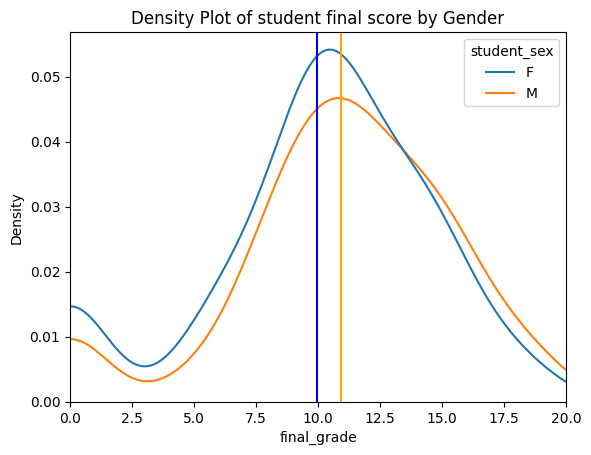

In [15]:
sns.kdeplot(student_math_df, x= 'final_grade', hue='student_sex')
plt.axvline(10.914439, color= 'Orange')
plt.axvline(9.966346, color= 'blue')
plt.xlim(0,20)
plt.title("Density Plot of student final score by Gender")
plt.show()

In the above plot, it is visible that average final grade for male students is greater than that of female students.

## Visualizations

**Q1: Histogram of grades**

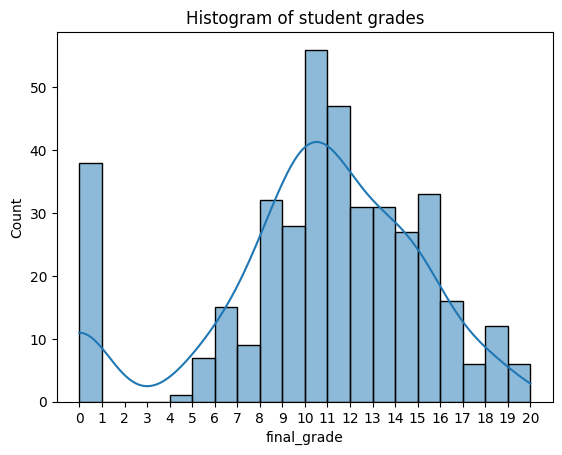

In [29]:
sns.histplot(student_math_df, x= 'final_grade', bins= 20, kde= True)
plt.title("Histogram of student grades")
plt.xticks(np.arange(0, 21, 1))
plt.show()

**Q2: Scatterplot: study time vs grades.**

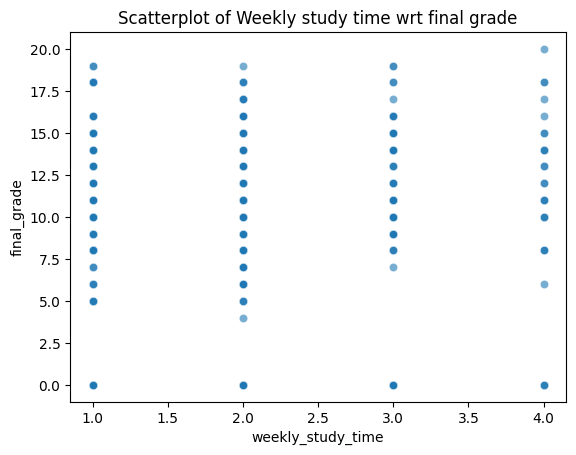

In [30]:
sns.scatterplot(student_math_df, x= 'weekly_study_time', y= 'final_grade', alpha= 0.6)
plt.title("Scatterplot of Weekly study time wrt final grade")
plt.show()

We are unable to understand the `scatterplot` as the data is very spread out for each value of study time. Hence, we are now going to use `pointplot` to understand the plot better.

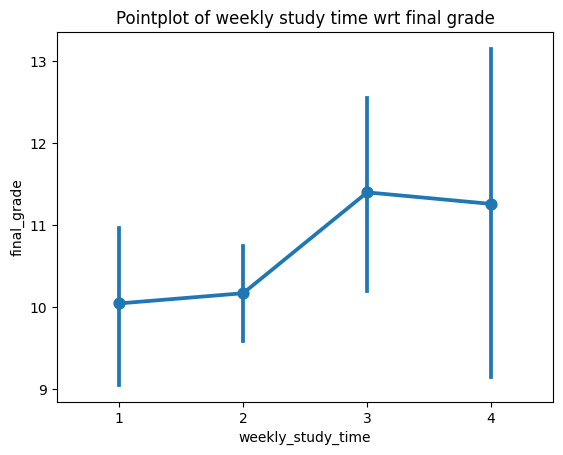

In [18]:
sns.pointplot(student_math_df, x= 'weekly_study_time', y= 'final_grade')
plt.title("Pointplot of weekly study time wrt final grade")
plt.show()

Based on the `pointplot` above, we can see that there is an increase in grades based on weekly study time, but the increase is not significant enough to warrant special attention, which is odd as we expect to see a larger correlation between these two attributes.

**Q3: Bar chart: male vs female average score.**

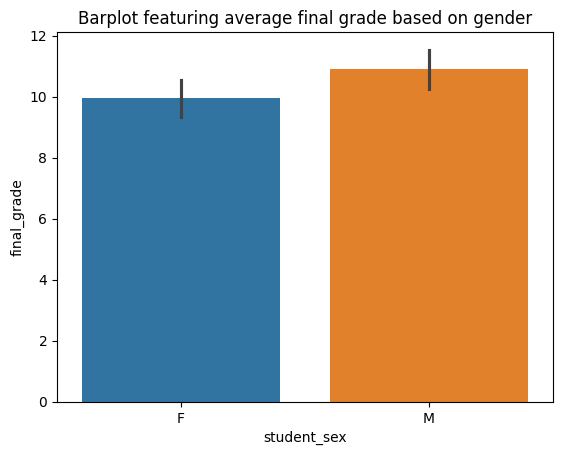

In [19]:
sns.barplot(student_math_df, y= 'final_grade', x= 'student_sex', hue= 'student_sex')
plt.title('Barplot featuring average final grade based on gender')
plt.show()

# Final Result

## Dataset cleaning

- The dataset was successfully loaded using Pandas.
- No missing values were found.
- No duplicate values were found.
- The dataset structure and data types were inspected before analysis.

-----

## Analysis Results

- Average Final Grade (G3): **10.42**
- Students Scoring Above 15: **40 students**
- Correlation Between Study Time and Final Grade: **0.0978 (Very Weak Correlation)**
- Average Final Grade by Gender:
    - Female Students: **9.97**
    - Male Students: **10.91**